# FIFA 23 Exploratory Data Analysis & Strategic Insights

This notebook contains the complete data science pipeline for analyzing the **FIFA 23 Player Dataset**:
- **Phase 1: Data Loading, Data Understanding, Exploration, Cleaning, & Feature Engineering**
- **Phase 2: Comprehensive Data Analysis (Univariate, Bivariate, Multivariate, Positional, Macro Demographics, & Strategic Scouting Metrics)**

---


## Phase 1: Data Loading, Cleaning & Feature Engineering

In [ ]:
# Stage 1: Setup & Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Set visual theme
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11

# Load raw dataset
df_raw = pd.read_csv("players_fifa23.csv", encoding="utf-8")
print(f"Dataset loaded successfully! Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")

In [1]:
# Stage 1: Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Set visual theme
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11

df_raw = pd.read_csv("players_fifa23.csv", encoding="utf-8")
print(f"Data loaded successfully! Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")

Data loaded successfully! Shape: 18539 rows, 90 columns


## Stage 2: Data Understanding

Here is the markdown table displaying only the selected columns retained for our EDA:

| Category | Column Name | Description & Analytical Use |
| --- | --- | --- |
| **Identification & Demographics** | `ID`, `FullName`, `PhotoUrl` | Unique player IDs, full names, and profile pictures. Used for indexing and labeling. |
| | `Age` | Player age. Useful for analyzing age distributions, player growth, and potential wonderkids. |
| | `Height`, `Weight` | Physical measurements. Correlation with positions and physical stats. |
| | `Nationality`, `Club`, `PreferredFoot` | Player country, club, and dominant foot. Analysis of league demographics. |
| **Financials** | `ValueEUR`, `WageEUR`, `ReleaseClause` | Transfer market value, weekly wage, and release clause. Useful for ROI, financial structures. |
| | `ContractUntil`, `ClubJoined` | Contract end year and join date. Useful for contract expiration analysis. |
| **Ratings & Potential** | `Overall`, `Potential`, `Growth` | Current rating, future ceiling rating, and potential growth. Core variables of player quality. |
| **Tactical Roles** | `Positions` | Playable positions. Used to aggregate stats by role. |
| | `NationalTeam` | International team presence. |
| **Work Rates** | `AttackingWorkRate`, `DefensiveWorkRate` | Tactical workrates (High/Medium/Low) in offense and defense. |
| **Core Face Attributes** | `PaceTotal`, `ShootingTotal`, `PassingTotal`, `DribblingTotal`, `DefendingTotal`, `PhysicalityTotal` | The six main stats representing pace, shooting, passing, dribbling, defense, and physical strength. |

In [2]:
# Filter the dataset to include only the selected 27 columns
selected_columns = [
    'ID', 'FullName', 'PhotoUrl', 'Age', 'Height', 'Weight', 
    'Nationality', 'Club', 'PreferredFoot', 'ValueEUR', 
    'WageEUR', 'ReleaseClause', 'ContractUntil', 'ClubJoined', 
    'Overall', 'Potential', 'Growth', 'Positions', 
    'NationalTeam', 'AttackingWorkRate', 'DefensiveWorkRate', 
    'PaceTotal', 'ShootingTotal', 'PassingTotal', 'DribblingTotal', 
    'DefendingTotal', 'PhysicalityTotal'
]

df = df_raw[selected_columns].copy()
print(f"Filtered dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Filtered dataset shape: 18539 rows, 27 columns


,ID,FullName,PhotoUrl,Age,Height,Weight,Nationality,Club,PreferredFoot,ValueEUR,...,Positions,NationalTeam,AttackingWorkRate,DefensiveWorkRate,PaceTotal,ShootingTotal,PassingTotal,DribblingTotal,DefendingTotal,PhysicalityTotal
0,158023,Lionel Messi,https://cdn.sofifa.net/players/158/023/23_60.png,35,169,67,Argentina,Paris Saint-Germain,Left,54000000,...,RW,Argentina,Low,Low,81,89,90,94,34,64
1,165153,Karim Benzema,https://cdn.sofifa.net/players/165/153/23_60.png,34,185,81,France,Real Madrid CF,Right,64000000,...,"CF,ST",France,Medium,Medium,80,88,83,87,39,78
2,188545,Robert Lewandowski,https://cdn.sofifa.net/players/188/545/23_60.png,33,185,81,Poland,FC Barcelona,Right,84000000,...,ST,Poland,High,Medium,75,91,79,86,44,83
3,192985,Kevin De Bruyne,https://cdn.sofifa.net/players/192/985/23_60.png,31,181,70,Belgium,Manchester City,Right,107500000,...,"CM,CAM",Belgium,High,High,74,88,93,87,64,77
4,231747,Kylian Mbappé,https://cdn.sofifa.net/players/231/747/23_60.png,23,182,73,France,Paris Saint-Germain,Right,190500000,...,"ST,LW",France,High,Low,97,89,80,92,36,76


## Stage 3: Data Exploration

In this stage, we perform initial data exploration on our filtered dataset, which includes:
- Checking data types and structures.
- Examining summary statistics for numerical and categorical attributes.
- Detecting duplicate records if they exist.
- Inspecting missing values across columns.

In [3]:
# Stage 3.1: Check Data Types & Structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18539 entries, 0 to 18538
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 18539 non-null  int64  
 1   FullName           18539 non-null  str    
 2   PhotoUrl           18539 non-null  str    
 3   Age                18539 non-null  int64  
 4   Height             18539 non-null  int64  
 5   Weight             18539 non-null  int64  
 6   Nationality        18539 non-null  str    
 7   Club               18539 non-null  str    
 8   PreferredFoot      18539 non-null  str    
 9   ValueEUR           18539 non-null  int64  
 10  WageEUR            18539 non-null  int64  
 11  ReleaseClause      18539 non-null  int64  
 12  ContractUntil      18447 non-null  float64
 13  ClubJoined         18539 non-null  int64  
 14  Overall            18539 non-null  int64  
 15  Potential          18539 non-null  int64  
 16  Growth             18539 non-null

In [4]:
# Stage 3.2: Summary Statistics
print("--- Numerical Columns Statistics ---")
display(df.describe())

print("\n--- Categorical Columns Statistics ---")
categorical_cols = df.select_dtypes(include=['object', 'str']).columns
if len(categorical_cols) > 0:
    display(df[categorical_cols].describe())
else:
    print("No categorical columns found.")

--- Numerical Columns Statistics ---


,ID,Age,Height,Weight,ValueEUR,WageEUR,ReleaseClause,ContractUntil,ClubJoined,Overall,Potential,Growth,PaceTotal,ShootingTotal,PassingTotal,DribblingTotal,DefendingTotal,PhysicalityTotal
count,18539.000000,18539.000000,18539.000000,18539.000000,1.853900e+04,18539.000000,1.853900e+04,18447.000000,18539.000000,18539.000000,18539.000000,18539.000000,18539.000000,18539.000000,18539.000000,18539.000000,18539.000000,18539.000000
mean,237011.899725,25.240412,181.550839,75.173904,2.875461e+06,8824.537462,5.081688e+06,2023.772266,2020.367442,65.852042,71.016668,5.164626,68.017746,53.777874,58.024327,63.109553,50.241383,64.775338
std,26714.860353,4.718163,6.858097,7.013593,7.635129e+06,19460.531154,1.467203e+07,1.258955,2.056372,6.788353,6.192866,5.374795,10.649511,13.619867,9.717950,9.336566,16.392532,9.577715
min,1179.000000,16.000000,155.000000,49.000000,0.000000e+00,0.000000,0.000000e+00,2022.000000,2002.000000,47.000000,48.000000,0.000000,28.000000,16.000000,25.000000,28.000000,15.000000,30.000000
25%,221663.000000,21.000000,177.000000,70.000000,4.750000e+05,1000.000000,6.650000e+05,2023.000000,2020.000000,62.000000,67.000000,0.000000,62.000000,44.000000,52.000000,58.000000,36.000000,58.000000
50%,241195.000000,25.000000,182.000000,75.000000,1.000000e+06,3000.000000,1.500000e+06,2024.000000,2021.000000,66.000000,71.000000,4.000000,69.000000,56.000000,59.000000,64.000000,54.000000,66.000000
75%,259059.000000,29.000000,186.000000,80.000000,2.000000e+06,8000.000000,3.400000e+06,2025.000000,2022.000000,70.000000,75.000000,9.000000,75.000000,64.000000,65.000000,69.000000,64.000000,72.000000
max,271817.000000,44.000000,206.000000,105.000000,1.905000e+08,450000.000000,3.667000e+08,2032.000000,2022.000000,91.000000,95.000000,26.000000,97.000000,92.000000,93.000000,94.000000,91.000000,91.000000



--- Categorical Columns Statistics ---


,FullName,PhotoUrl,Nationality,Club,PreferredFoot,Positions,NationalTeam,AttackingWorkRate,DefensiveWorkRate
count,18539,18539,18539,18539,18539,18539,18539,18539,18539
unique,18337,18420,160,679,2,693,36,3,3
top,Emmanuel Boateng,https://cdn.sofifa.net/players/246/748/23_60.png,England,Free agent,Right,CB,Not in team,Medium,Medium
freq,3,2,1632,92,14045,2433,17722,12204,13613


In [5]:
# Stage 3.3: Duplicate Detection
duplicates_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates_count}")

Number of duplicate rows: 119


In [6]:
# Stage 3.4: Missing Values Analysis
missing_values = df.isnull().sum()
missing_columns = missing_values[missing_values > 0]

if not missing_columns.empty:
    print("Columns with missing values and counts:")
    display(missing_columns.to_frame(name="Missing Count").sort_values(by="Missing Count", ascending=False))
else:
    print("No missing values found in any columns!")

Columns with missing values and counts:


,Missing Count
ContractUntil,92


## Stage 4: Data Cleaning

In this stage, we execute the cleaning operations identified during our data exploration:
1. Drop duplicate records in-place.
2. Handle missing values in the `ContractUntil` column by replacing them with `'unknown'`.
3. Perform in-depth checks on categorical columns.

In [7]:
# Stage 4.1: Handle Duplicate Rows
print(f"Dataset shape before dropping duplicates: {df.shape}")
df.drop_duplicates(inplace=True)
print(f"Dataset shape after dropping duplicates: {df.shape}")

Dataset shape before dropping duplicates: (18539, 27)
Dataset shape after dropping duplicates: (18420, 27)


In [8]:
# Stage 4.2: Handle Missing Values
# Fill missing values in 'ContractUntil' with 'unknown'
df['ContractUntil'] = df['ContractUntil'].fillna('unknown')
print("Missing values in 'ContractUntil' after cleaning:", df['ContractUntil'].isnull().sum())

Missing values in 'ContractUntil' after cleaning: 0


In [9]:
# Stage 4.3: In-depth Categorical Column Check
categorical_cols = df.select_dtypes(include=['object', 'str']).columns

print(f"Checking {len(categorical_cols)} categorical columns for anomalies:\n")
for col in categorical_cols:
    nunique = df[col].nunique()
    unique_vals = df[col].unique()
    print(f"=== Column: {col} (Nunique: {nunique}) ===")
    if nunique <= 30:
        print("Unique values:", list(unique_vals))
    else:
        print("Unique values (first 30):", list(unique_vals[:30]))
    print('-' * 60)

Checking 10 categorical columns for anomalies:

=== Column: FullName (Nunique: 18337) ===
Unique values (first 30): ['Lionel Messi', 'Karim Benzema', 'Robert Lewandowski', 'Kevin De Bruyne', 'Kylian Mbappé', 'Mohamed Salah', 'Thibaut Courtois', 'Manuel Neuer', 'C. Ronaldo dos Santos Aveiro', 'Virgil van Dijk', 'Harry Kane', 'Neymar da Silva Santos Jr.', 'Heung Min Son', 'Carlos Henrique Venancio Casimiro', 'Jan Oblak', 'Sadio Mané', 'Ederson Santana de Moraes', 'Joshua Kimmich', 'Alisson Ramses Becker', "N'Golo Kanté", 'Rúben Santos Gato Alves Dias', 'Erling Haaland', 'Gianluigi Donnarumma', 'Bernardo Mota Carvalho e Silva', 'João Pedro Cavaco Cancelo', 'Marcos Aoás Corrêa', 'Keylor Navas', 'Marc-André ter Stegen', 'Toni Kroos', 'Luka Modrić']
------------------------------------------------------------
=== Column: PhotoUrl (Nunique: 18420) ===
Unique values (first 30): ['https://cdn.sofifa.net/players/158/023/23_60.png', 'https://cdn.sofifa.net/players/165/153/23_60.png', 'https://cdn

=== Column: Club (Nunique: 679) ===
Unique values (first 30): ['Paris Saint-Germain', 'Real Madrid CF', 'FC Barcelona', 'Manchester City', 'Liverpool', 'FC Bayern München', 'Manchester United', 'Tottenham Hotspur', 'Atlético de Madrid', 'Chelsea', 'AC Milan', 'Lazio', 'Inter', 'Roma', 'Juventus', 'Eintracht Frankfurt', 'Villarreal CF', 'RB Leipzig', 'Borussia Dortmund', 'Real Betis Balompié', 'RC Celta de Vigo', 'Sevilla FC', 'Leicester City', 'Bayer 04 Leverkusen', 'Borussia Mönchengladbach', 'Galatasaray SK', 'Club Nacional de Football', 'Ajax', 'U.S. Sassuolo Calcio', 'Arsenal']
------------------------------------------------------------
=== Column: PreferredFoot (Nunique: 2) ===
Unique values: ['Left', 'Right']
------------------------------------------------------------
=== Column: ContractUntil (Nunique: 10) ===
Unique values: [2023.0, 2025.0, 2024.0, 2026.0, 2027.0, 2022.0, 2028.0, 'unknown', 2031.0, 2032.0]
------------------------------------------------------------
=== Colum

## Stage 5: Feature Extraction

In this stage, we extract new columns from the existing dataset to add more value for subsequent modeling and analysis:
1. **BMI (Body Mass Index)**: Calculate BMI from height and weight for physical profiling.
2. **PositionGroup**: Map the specific playable roles into four broad groups (`Goalkeeper`, `Defender`, `Midfielder`, `Forward`).
3. **IsNationalPlayer**: Create a boolean flag indicating whether the player plays for a national squad.
4. **ValuePerOverall**: Calculate the financial value per overall rating point.

In [10]:
# Stage 5.1: Calculate BMI (Body Mass Index)
# Weight is in kg, Height is in cm (converted to meters by dividing by 100)
df['BMI'] = df['Weight'] / ((df['Height'] / 100) ** 2)
df['BMI'] = df['BMI'].round(2)
print("BMI column successfully created!")
df[['FullName', 'Height', 'Weight', 'BMI']].head()

BMI column successfully created!


,FullName,Height,Weight,BMI
0,Lionel Messi,169,67,23.46
1,Karim Benzema,185,81,23.67
2,Robert Lewandowski,185,81,23.67
3,Kevin De Bruyne,181,70,21.37
4,Kylian Mbappé,182,73,22.04


In [11]:
# Stage 5.2: Categorize Broad Position Group
def get_position_group(pos_string):
    primary_pos = pos_string.split(',')[0].strip()
    
    if primary_pos == 'GK':
        return 'Goalkeeper'
    elif primary_pos in ['CB', 'LB', 'RB', 'LWB', 'RWB']:
        return 'Defender'
    elif primary_pos in ['CM', 'CDM', 'CAM', 'LM', 'RM']:
        return 'Midfielder'
    elif primary_pos in ['ST', 'CF', 'LW', 'RW']:
        return 'Forward'
    else:
        return 'Other'

df['PositionGroup'] = df['Positions'].apply(get_position_group)
print("PositionGroup column successfully created!")
print(df['PositionGroup'].value_counts())

PositionGroup column successfully created!


PositionGroup
Midfielder    6603
Defender      6204
Forward       3560
Goalkeeper    2053
Name: count, dtype: int64


In [12]:
# Stage 5.3: National Player Status Flag
df['IsNationalPlayer'] = df['NationalTeam'] != 'Not in team'
print("IsNationalPlayer column successfully created!")
print(df['IsNationalPlayer'].value_counts())

IsNationalPlayer column successfully created!
IsNationalPlayer
False    17625
True       795
Name: count, dtype: int64


In [13]:
# Stage 5.4: Financial Value Per Overall Rating Point
df['ValuePerOverall'] = (df['ValueEUR'] / df['Overall']).round(2)
print("ValuePerOverall column successfully created!")
df[['FullName', 'Overall', 'ValueEUR', 'ValuePerOverall']].head()

# Phase 2: Data Analysis Stage

In this phase, we perform deep visual and statistical analyses structured into 5 core modules:
1. **Univariate Analysis & Data Distributions**
2. **Bivariate & Financial Dynamics Analysis**
3. **Multivariate & Positional Deep-Dives**
4. **Macro Demographics & Club / Country Benchmarking**
5. **Advanced Strategic Metrics & Value-for-Money**

## Module 1: Univariate Analysis & Data Distributions

### 1.1 Player Demographics: Age & Physical Attributes (Height, Weight, BMI)

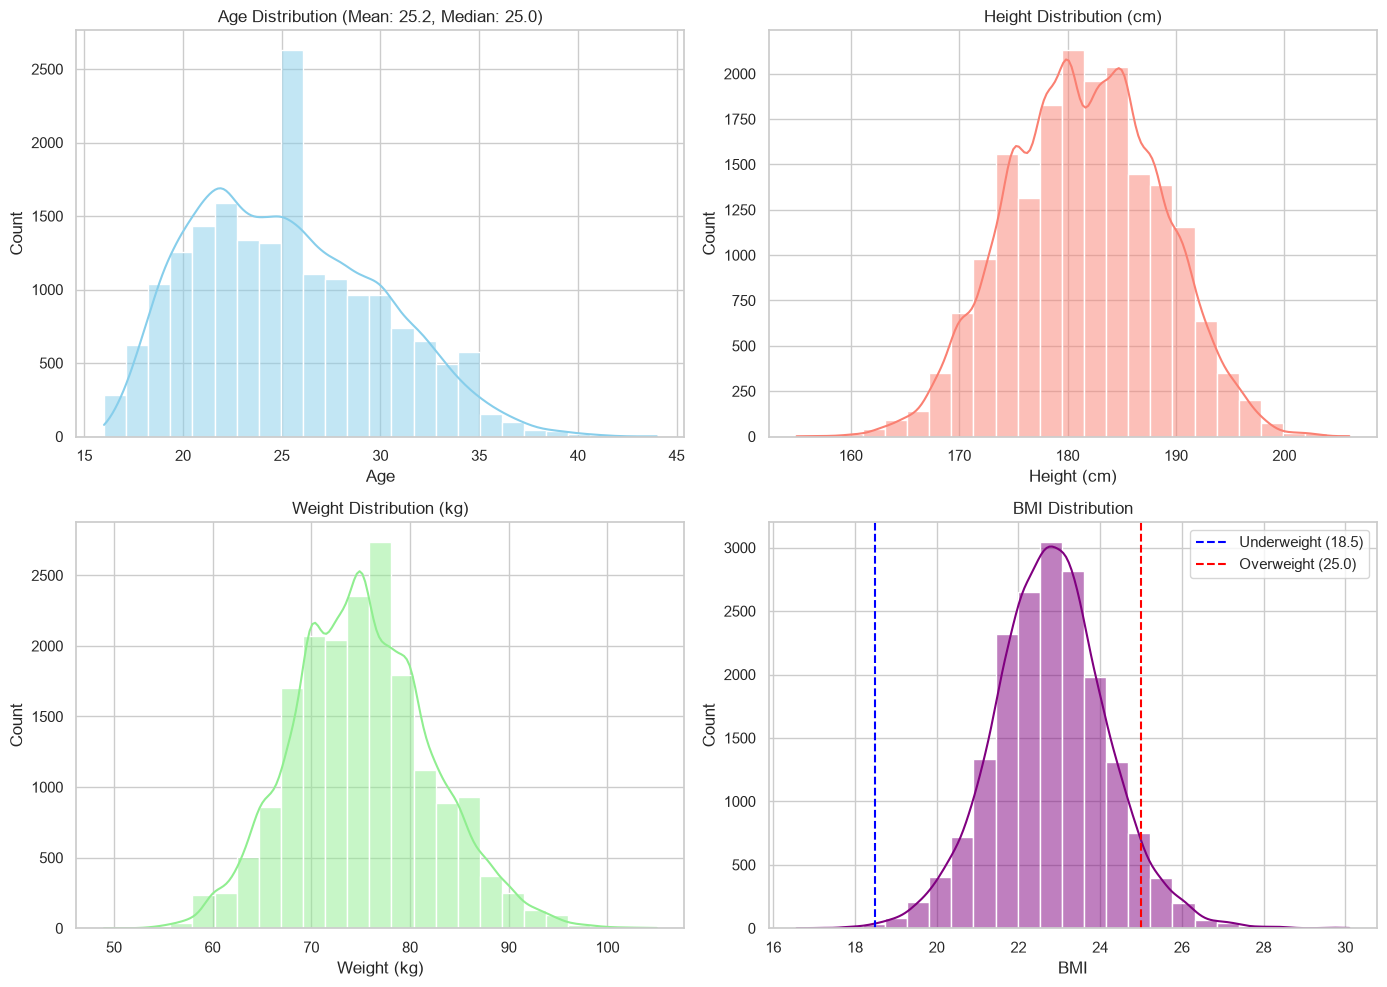

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age Distribution
sns.histplot(df['Age'], kde=True, ax=axes[0, 0], color='skyblue', bins=25)
axes[0, 0].set_title(f'Age Distribution (Mean: {df["Age"].mean():.1f}, Median: {df["Age"].median():.1f})')
axes[0, 0].set_xlabel('Age')

# Height Distribution
sns.histplot(df['Height'], kde=True, ax=axes[0, 1], color='salmon', bins=25)
axes[0, 1].set_title('Height Distribution (cm)')
axes[0, 1].set_xlabel('Height (cm)')

# Weight Distribution
sns.histplot(df['Weight'], kde=True, ax=axes[1, 0], color='lightgreen', bins=25)
axes[1, 0].set_title('Weight Distribution (kg)')
axes[1, 0].set_xlabel('Weight (kg)')

# BMI Distribution
sns.histplot(df['BMI'], kde=True, ax=axes[1, 1], color='purple', bins=25)
axes[1, 1].axvline(18.5, color='blue', linestyle='--', label='Underweight (18.5)')
axes[1, 1].axvline(25.0, color='red', linestyle='--', label='Overweight (25.0)')
axes[1, 1].set_title('BMI Distribution')
axes[1, 1].set_xlabel('BMI')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

> **Key Takeaway**: Player ages range from 16 to 44 with a median of **25 years**. The BMI distribution shows that the vast majority of professional players fall within the optimal athletic range of **20–25**.

### 1.2 Overall Rating vs Potential Rating Spectrum

In [15]:
fig = px.histogram(df, x=['Overall', 'Potential'], barmode='overlay', 
                   title='Comparison of Overall Rating vs. Potential Rating Spectrum',
                   labels={'value': 'Rating Score', 'variable': 'Metric'},
                   color_discrete_map={'Overall': '#1f77b4', 'Potential': '#ff7f0e'},
                   opacity=0.7, nbins=35)
fig.update_layout(xaxis_title="Rating Score", yaxis_title="Number of Players")
fig.show()

### 1.3 Financial Metrics Distribution (Value & Wage)

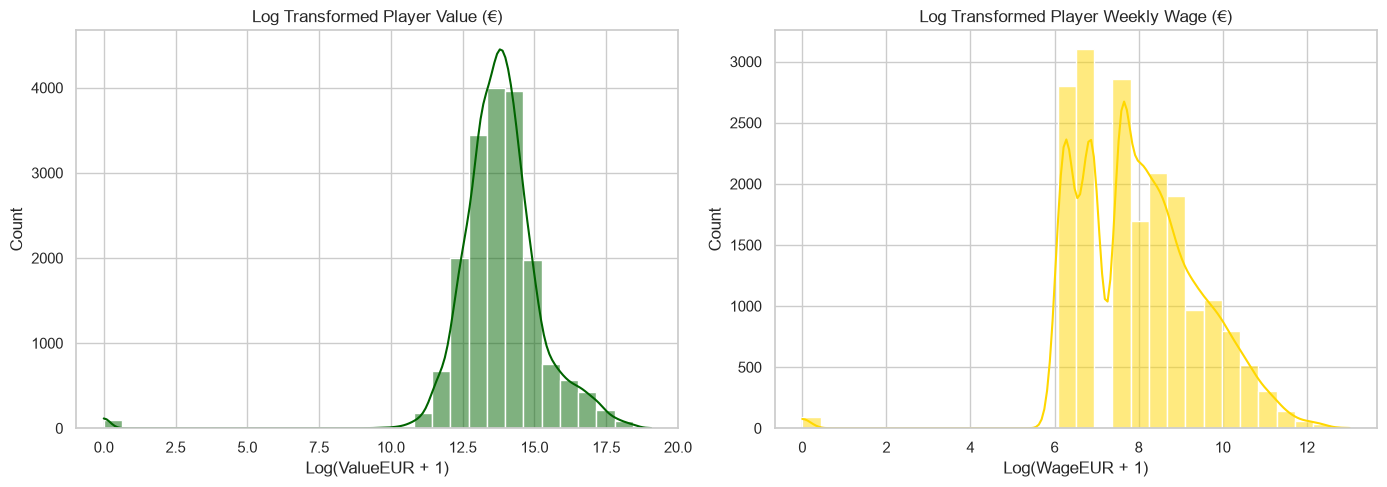

--- Value & Wage Summary (EUR) ---


,ValueEUR,WageEUR,ReleaseClause
count,"18,420","18,420","18,420"
mean,"2,842,697","8,733","5,015,212"
std,"7,645,260","19,452","14,686,055"
min,0,0,0
25%,"475,000","1,000","660,000"
50%,"975,000","3,000","1,500,000"
75%,"2,000,000","7,000","3,300,000"
max,"190,500,000","450,000","366,700,000"


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log ValueEUR
sns.histplot(np.log1p(df['ValueEUR']), kde=True, ax=axes[0], color='darkgreen', bins=30)
axes[0].set_title('Log Transformed Player Value (€)')
axes[0].set_xlabel('Log(ValueEUR + 1)')

# Log WageEUR
sns.histplot(np.log1p(df['WageEUR']), kde=True, ax=axes[1], color='gold', bins=30)
axes[1].set_title('Log Transformed Player Weekly Wage (€)')
axes[1].set_xlabel('Log(WageEUR + 1)')

plt.tight_layout()
plt.show()

# Summary statistics
print("--- Value & Wage Summary (EUR) ---")
display(df[['ValueEUR', 'WageEUR', 'ReleaseClause']].describe().map(lambda x: f"{x:,.0f}"))

> **Key Takeaway**: Raw financial values are right-skewed due to elite players holding extreme valuations. Applying log transformations normalizes the distribution and highlights clear wage tiers across leagues.

### 1.4 Categorical Profile: Position Group, Dominant Foot & Work Rates

C:\Users\Windows 10\AppData\Local\Temp\ipykernel_17872\4178839050.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='PositionGroup', ax=axes[0], palette='viridis')


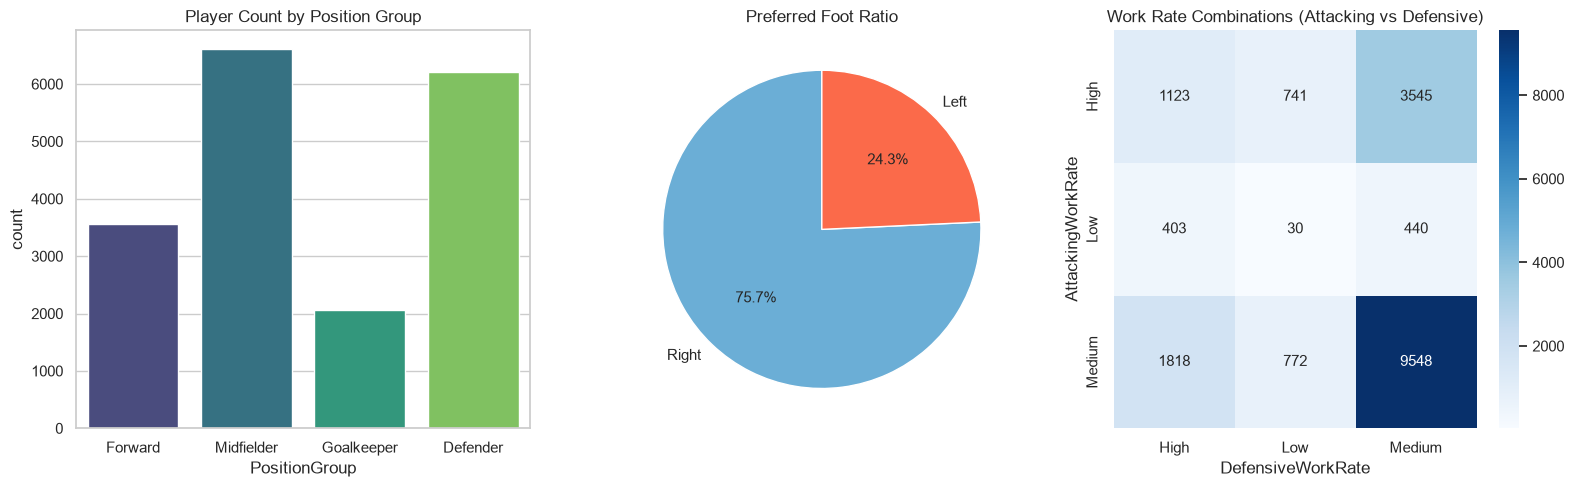

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Position Group
sns.countplot(data=df, x='PositionGroup', ax=axes[0], palette='viridis')
axes[0].set_title('Player Count by Position Group')

# Preferred Foot
foot_counts = df['PreferredFoot'].value_counts()
axes[1].pie(foot_counts, labels=foot_counts.index, autopct='%1.1f%%', colors=['#6baed6', '#fb6a4a'], startangle=90)
axes[1].set_title('Preferred Foot Ratio')

# Work Rates Heatmap Count
workrate_ct = pd.crosstab(df['AttackingWorkRate'], df['DefensiveWorkRate'])
sns.heatmap(workrate_ct, annot=True, fmt='d', cmap='Blues', ax=axes[2])
axes[2].set_title('Work Rate Combinations (Attacking vs Defensive)')

plt.tight_layout()
plt.show()

## Module 2: Bivariate & Financial Dynamics Analysis

### 2.1 Overall Rating vs Market Value & Wage Dynamics

In [18]:
fig = px.scatter(df.sample(min(5000, len(df)), random_state=42), 
                 x='Overall', y='ValueEUR', color='PositionGroup',
                 hover_name='FullName', hover_data=['Club', 'Age', 'WageEUR'],
                 title='Overall Rating vs. Market Value (€) (Sample of 5,000 Players)',
                 labels={'ValueEUR': 'Market Value (€)', 'Overall': 'Overall Rating'},
                 log_y=True)
fig.show()

> **Key Takeaway**: Market value scales exponentially with Overall rating. Players with an Overall rating > 85 command disproportionately high market valuations and wage packages.

### 2.2 Age Curve & Performance Lifecycle

C:\Users\Windows 10\AppData\Local\Temp\ipykernel_17872\3549429349.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Age', y='Overall', palette='magma')


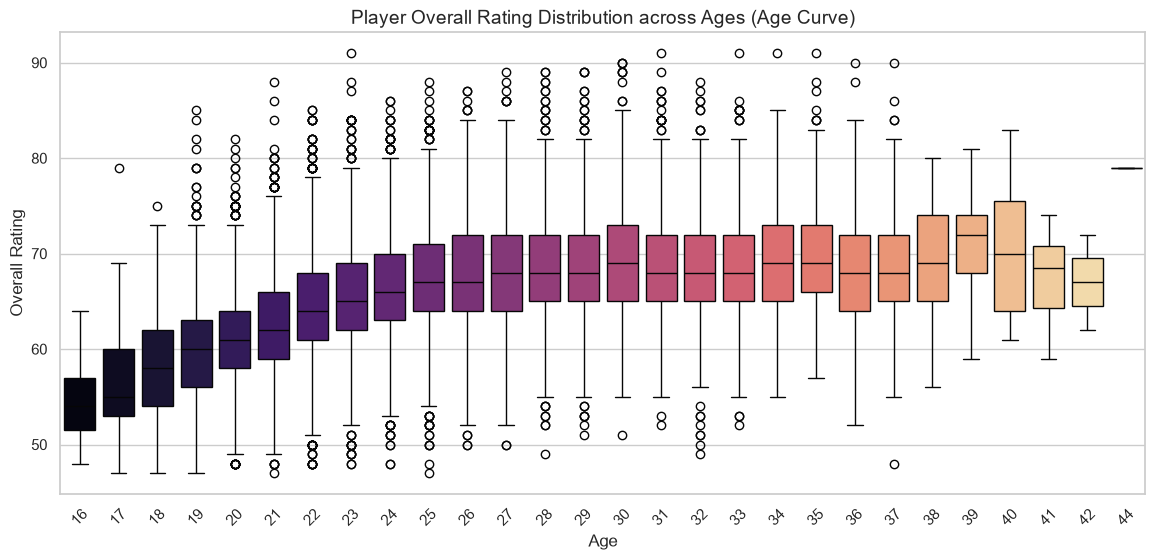

In [19]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='Age', y='Overall', palette='magma')
plt.title('Player Overall Rating Distribution across Ages (Age Curve)', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Overall Rating')
plt.xticks(rotation=45)
plt.show()

> **Key Takeaway**: Peak average performance is maintained between ages **26 and 30**. Below age 22, overall ratings show a wider spread with high headroom for potential growth.

### 2.3 Wonderkids & High-Growth Gems

In [20]:
# Define Wonderkid Criteria: Age <= 21, Potential >= 80, Growth >= 10
wonderkids = df[(df['Age'] <= 21) & (df['Potential'] >= 80) & (df['Growth'] >= 10)].sort_values(by='Potential', ascending=False)
print(f"Total Wonderkids identified: {len(wonderkids)}")

# Display Top 10 Wonderkids
display(wonderkids[['FullName', 'Age', 'Club', 'PositionGroup', 'Overall', 'Potential', 'Growth', 'ValueEUR']].head(10))

# Plot Top 15 Wonderkids
fig = px.bar(wonderkids.head(15), x='FullName', y=['Overall', 'Growth'],
             title='Top 15 Wonderkids (Current Overall vs Growth Potential)',
             labels={'value': 'Rating Score', 'variable': 'Metric', 'FullName': 'Player'},
             barmode='stack')
fig.show()

Total Wonderkids identified: 523


,FullName,Age,Club,PositionGroup,Overall,Potential,Growth,ValueEUR
527,Anssumane Fati,19,FC Barcelona,Forward,79,90,11,38000000
1584,Alberto Moleiro González,18,Unión Deportiva Las Palmas,Midfielder,75,90,15,13000000
526,Ryan Gravenberch,20,FC Bayern München,Midfielder,79,89,10,38500000
541,Eduardo Camavinga,19,Real Madrid CF,Midfielder,79,89,10,38000000
2922,Rayan Cherki,18,Olympique Lyonnais,Forward,73,88,15,7000000
685,Charles De Ketelaere,21,AC Milan,Forward,78,88,10,32000000
6918,Antonio Nusa,17,Club Brugge KV,Forward,68,88,20,3300000
686,Gabriel Teodoro Martinelli Silva,21,Arsenal,Midfielder,78,88,10,31500000
1300,Khvicha Kvaratskhelia,21,Napoli,Forward,76,88,12,18500000
5658,Youssoufa Moukoko,17,Borussia Dortmund,Forward,69,88,19,3500000


### 2.4 Attribute Correlation Matrix Heatmap

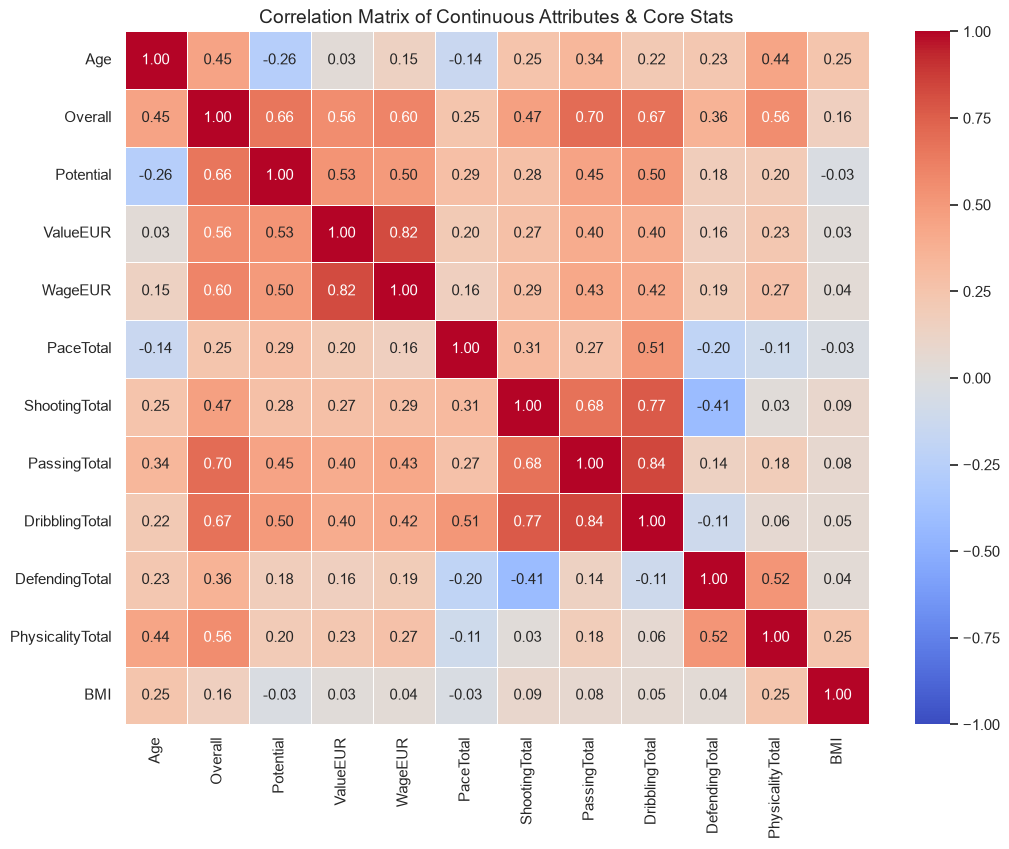

In [21]:
num_cols = ['Age', 'Overall', 'Potential', 'ValueEUR', 'WageEUR', 
            'PaceTotal', 'ShootingTotal', 'PassingTotal', 'DribblingTotal', 
            'DefendingTotal', 'PhysicalityTotal', 'BMI']

plt.figure(figsize=(12, 9))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix of Continuous Attributes & Core Stats', fontsize=14)
plt.show()

## Module 3: Multivariate & Positional Deep-Dives

### 3.1 Skill Profiles by Position Group (Radar Chart)

In [22]:
face_stats = ['PaceTotal', 'ShootingTotal', 'PassingTotal', 'DribblingTotal', 'DefendingTotal', 'PhysicalityTotal']
pos_profile = df[df['PositionGroup'] != 'Goalkeeper'].groupby('PositionGroup')[face_stats].mean().reset_index()

fig = go.Figure()
categories = face_stats

for i, row in pos_profile.iterrows():
    fig.add_trace(go.Scatterpolar(
        r=[row[c] for c in categories],
        theta=categories,
        fill='toself',
        name=row['PositionGroup']
    ))

fig.update_layout(
  polar=dict(radialaxis=dict(visible=True, range=[30, 85])),
  showlegend=True,
  title="Average Core Attribute Footprint by Position Group (Outfield Players)"
)
fig.show()

> **Key Takeaway**: Radar chart illustrates clear tactical roles: Defenders dominate Defending & Physicality; Midfielders lead in Passing & Dribbling; Forwards excel in Pace & Shooting.

### 3.2 Dominant Foot Valuation & Rating Impact by Position

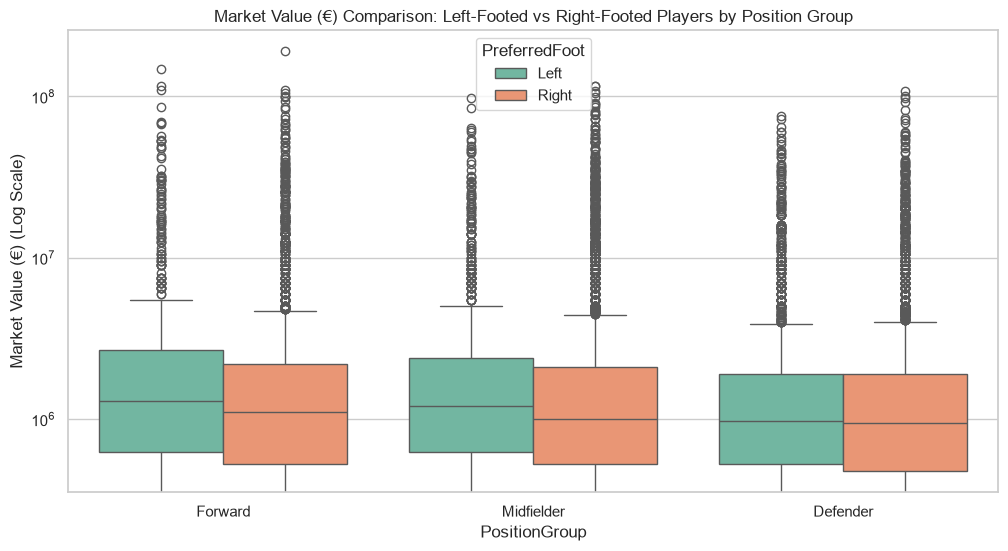

In [23]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[df['PositionGroup'] != 'Goalkeeper'], x='PositionGroup', y='ValueEUR', hue='PreferredFoot', palette='Set2')
plt.yscale('log')
plt.title('Market Value (€) Comparison: Left-Footed vs Right-Footed Players by Position Group')
plt.ylabel('Market Value (€) (Log Scale)')
plt.show()

## Module 4: Macro Demographics & Club / Country Benchmarking

### 4.1 Top 10 Most Valuable Squads & Payroll Efficiency

In [24]:
club_stats = df[df['Club'] != 'Free agent'].groupby('Club').agg(
    Total_Value=('ValueEUR', 'sum'),
    Total_Wage=('WageEUR', 'sum'),
    Avg_Overall=('Overall', 'mean'),
    Squad_Size=('ID', 'count')
).reset_index()

top10_valuable = club_stats.sort_values(by='Total_Value', ascending=False).head(10)

fig = px.bar(top10_valuable, x='Total_Value', y='Club', orientation='h',
             color='Avg_Overall', color_continuous_scale='Viridis',
             title='Top 10 Most Valuable Clubs by Total Squad Market Value (€)',
             labels={'Total_Value': 'Total Market Value (€)', 'Avg_Overall': 'Avg Rating'})
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

### 4.2 Country Talent Demographics & Rating Leadership

C:\Users\Windows 10\AppData\Local\Temp\ipykernel_17872\2323788785.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_volume, y='Nationality', x='Player_Count', ax=axes[0], palette='Blues_r')
C:\Users\Windows 10\AppData\Local\Temp\ipykernel_17872\2323788785.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_nations_rating, y='Nationality', x='Avg_Rating', ax=axes[1], palette='Greens_r')


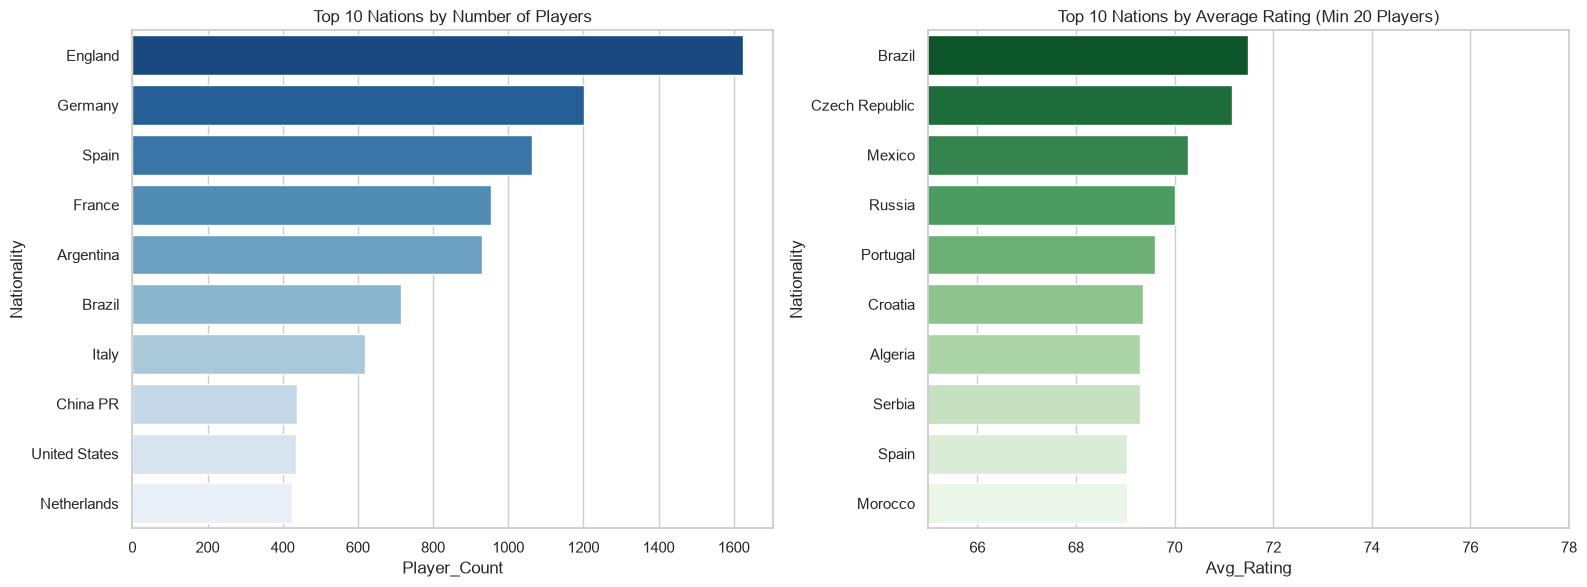

In [25]:
country_stats = df.groupby('Nationality').agg(
    Player_Count=('ID', 'count'),
    Avg_Rating=('Overall', 'mean'),
    Total_Value=('ValueEUR', 'sum')
).reset_index()

top_nations_rating = country_stats[country_stats['Player_Count'] >= 20].sort_values(by='Avg_Rating', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top Nations by Volume
top_volume = country_stats.sort_values(by='Player_Count', ascending=False).head(10)
sns.barplot(data=top_volume, y='Nationality', x='Player_Count', ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 10 Nations by Number of Players')

# Top Nations by Quality
sns.barplot(data=top_nations_rating, y='Nationality', x='Avg_Rating', ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 10 Nations by Average Rating (Min 20 Players)')
axes[1].set_xlim(65, 78)

plt.tight_layout()
plt.show()

### 4.3 Contract Expiration Analysis (Targeting Impending Free Transfers)

In [26]:
# Expiring in 2023 or 2024 with value > 5M
expiring_soon = df[(df['ContractUntil'].isin([2023.0, 2024.0, '2023', '2024'])) & (df['ValueEUR'] > 5000000)].sort_values(by='ValueEUR', ascending=False)
print(f"High-Value Bargains entering contract final years: {len(expiring_soon)}")

display(expiring_soon[['FullName', 'Club', 'Age', 'Overall', 'Potential', 'ContractUntil', 'ValueEUR', 'WageEUR']].head(10))

High-Value Bargains entering contract final years: 821


,FullName,Club,Age,Overall,Potential,ContractUntil,ValueEUR,WageEUR
4,Kylian Mbappé,Paris Saint-Germain,23,91,95,2024.0,190500000,230000
5,Mohamed Salah,Liverpool,30,90,90,2023.0,115500000,270000
83,Phil Foden,Manchester City,22,85,92,2024.0,109500000,180000
10,Harry Kane,Tottenham Hotspur,28,89,89,2024.0,105500000,240000
61,Christopher Nkunku,RB Leipzig,24,86,89,2024.0,94000000,90000
25,Marcos Aoás Corrêa,Paris Saint-Germain,28,88,90,2024.0,92000000,170000
14,Jan Oblak,Atlético de Madrid,29,89,91,2023.0,85500000,100000
64,Sergej Milinković-Savić,Lazio,27,86,87,2024.0,77500000,90000
36,Marco Verratti,Paris Saint-Germain,29,87,87,2024.0,77500000,155000
19,N'Golo Kanté,Chelsea,31,89,89,2023.0,72000000,220000


## Module 5: Advanced Strategic Metrics & Value-for-Money

### 5.1 Value-for-Money Index: Identifying Undervalued High Performers

In [27]:
# Filter high rating players (Overall >= 75) with low market value per overall point
undervalued = df[(df['Overall'] >= 75) & (df['Age'] <= 28)].sort_values(by='ValuePerOverall', ascending=True)

fig = px.scatter(undervalued.head(30), x='ValuePerOverall', y='Overall',
                 size='Potential', color='PositionGroup', hover_name='FullName',
                 hover_data=['Club', 'WageEUR', 'ValueEUR'],
                 title='Top 30 High-Performance Bargain Targets (Overall >= 75, Age <= 28)',
                 labels={'ValuePerOverall': 'Value (€) Per Overall Rating Point'})
fig.show()

# Data Cleaning & Streamlit Export

The following cell performs the complete cleaning and feature engineering process on the raw dataset and outputs a reduced, preprocessed file `cleaned_data.csv` for the Streamlit dashboard.

In [ ]:
import pandas as pd

# 1. Load raw dataset
df_raw = pd.read_csv('players_fifa23.csv', encoding='utf-8')

# 2. Select columns of interest for the scouting dashboard
selected_columns = [
    'ID', 'FullName', 'PhotoUrl', 'Age', 'Height', 'Weight',
    'Nationality', 'Club', 'PreferredFoot', 'ValueEUR',
    'WageEUR', 'ReleaseClause', 'ContractUntil', 'ClubJoined',
    'Overall', 'Potential', 'Growth', 'Positions',
    'NationalTeam', 'AttackingWorkRate', 'DefensiveWorkRate',
    'PaceTotal', 'ShootingTotal', 'PassingTotal', 'DribblingTotal',
    'DefendingTotal', 'PhysicalityTotal'
]
df = df_raw[selected_columns].copy()

# 3. Remove duplicates
df.drop_duplicates(inplace=True)

# 4. Impute missing contract values
df['ContractUntil'] = df['ContractUntil'].fillna('unknown')

# 5. Engineer metrics (BMI, general position role, value efficiency, national status)
df['BMI'] = (df['Weight'] / ((df['Height'] / 100) ** 2)).round(2)

def get_position_group(pos_string):
    primary_pos = str(pos_string).split(',')[0].strip()
    if primary_pos == 'GK':
        return 'Goalkeeper'
    elif primary_pos in ['CB', 'LB', 'RB', 'LWB', 'RWB']:
        return 'Defender'
    elif primary_pos in ['CM', 'CDM', 'CAM', 'LM', 'RM']:
        return 'Midfielder'
    elif primary_pos in ['ST', 'CF', 'LW', 'RW']:
        return 'Forward'
    else:
        return 'Other'

df['PositionGroup'] = df['Positions'].apply(get_position_group)
df['IsNationalPlayer'] = df['NationalTeam'] != 'Not in team'
df['ValuePerOverall'] = (df['ValueEUR'] / df['Overall']).round(2)

# 6. Export to CSV for the Streamlit dashboard
df.to_csv('cleaned_data.csv', index=False, encoding='utf-8')
print('Successfully exported cleaned_data.csv!')